# Quickstart: fit a mock galaxy

A star-forming galaxy with six SDSS+WISE bands, fitted with NUTS on a
differentiable JAX forward model. About two minutes on a laptop.

The recipe here is `mock_recovery_minimal`: truncated-skew-normal SFH,
Calzetti birth-cloud dust, nebular off, redshift fixed at 0.05. Seven
free parameters. See `04_building_models.py` for the recipe grammar and
`02_sed_anatomy.py` for a panchromatic model with nebular, AGN, dust IR,
and IGM enabled.

In [1]:
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import tengri
from tengri import (
    ForwardModel,
    Observation,
    Photometry,
    SEDModel,
    citations,
    cosmology,
    generate_mock,
    load_ssp_data,
    plot,
    recipes,
)
from tengri.utils.conversions import lnu_to_fnu

plot.setup_style()
FIG_DIR = Path("_figs")
FIG_DIR.mkdir(exist_ok=True)

C_POST, C_TRUTH, C_DATA = "#3a76d9", "0.15", "#c3372a"

W0523 17:58:42.173253 2398524 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


## Stellar library and observation

`mock_recovery_minimal` works with any SSP file; the Cue-based recipes
would require a bare-stellar grid like the one downloaded below.

In [2]:
SSP_NAME = "fsps_prsc_miles_chabrier"
ssp_path = Path("../data") / f"{SSP_NAME}.h5"
if not ssp_path.exists():
    ssp_path = Path(tengri.download_ssp(SSP_NAME))
ssp = load_ssp_data(str(ssp_path))

FILTERS = ["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z", "wise_w1"]
obs = Observation(photometry=Photometry.from_names(FILTERS))

## Build the model

`model.summary()` prints the assembled pipeline; `citations.print_citations`
pulls the bibliography of every physics ingredient straight from the
registry — enough for the methods section of a paper.

In [3]:
sed_model = SEDModel.build(
    ssp_data=ssp,
    observation=obs,
    **recipes.mock_recovery_minimal(),
)
forward = ForwardModel.build(sed=sed_model, observation=obs)

print(sed_model.summary())
citations.print_citations(sed_model)

/Users/suchethacooray/.claude-squad/worktrees/cs/quickstart-rewrite_18b24c8f11aec178/src/tengri/forward/sed_model.py:972: BakedInNebularWarning: BakedInBackend: nebular emission is baked into the SSP file at a FIXED logU and FIXED escape fraction determined when the SSP grid was generated (commonly logU = −3, but depends on the SSP file). The ionization parameter and escape fraction are NOT free parameters — varying neb_logU or neb_fesc in your Parameters will have no effect. Check your SSP file's nebular assumptions. Switch to CloudyGridBackend or CueBackend to vary nebular properties. To suppress: pass ionizing_source_warning='suppress'.
  self._nebular_backend = BakedInBackend()


Model  SFH: tsnorm
──────────────────────────────────────────────────────────────────
  SSP grid:    15 Z × 93 ages × 5994 λ [91–100000000 Å]
  Filters:     6 bands
  Redshift:    0.0500 (fixed)
  Dtype:       float64
  Precomputed: photometry
  Components:  igm

  Pipeline (4 components):
    1. stellar        [sfh_model=tsnorm, metallicity_model=delta, n_grid=64]
    2. nebular        [backend=baked_in]
    3. dust           [law_bc=calzetti, law_diff=calzetti]
    4. igm

  Parameters:  7 free
──────────────────────────────────────────────────────────────────
Please cite the following when publishing results that use tengri:

  [1] Cooray et al. (2026, Paper I)  —  SED fitting framework — methods paper (this package)
       {tengri: Differentiable SED fitting with Information-Field-Theory star formation history priors. I. Framework and mock recovery}

  [2] Bradbury et al. (2018)  —  Autodiff framework and XLA compiler integration
       {JAX}: composable transformations of {P}ython

## Mock observation

One draw from the prior is the truth. `generate_mock` returns the
noiseless model fluxes, Gaussian uncertainties at the requested SNR,
and a noisy realisation.

In [4]:
key = jax.random.PRNGKey(7)
key_truth, key_mock, key_fit = jax.random.split(key, 3)

truth = sed_model.spec.sample(key_truth)
mock = generate_mock(sed_model, truth, key=key_mock, snr=30.0)
flux_obs = np.asarray(mock["flux_obs"])
noise = np.asarray(mock["noise"])

phot = obs.photometry
wave_eff_um = (
    np.array(
        [
            np.trapezoid(w * t, w) / np.trapezoid(t, w)
            for w, t in zip(phot.filter_waves, phot.filter_trans)
        ]
    )
    / 1e4
)

W0523 17:58:44.964729 2398409 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0523 17:58:45.268254 2398409 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


## Fit

In [5]:
posterior = forward.fit(
    flux_obs,
    noise,
    method="mcmc_nuts",
    key=key_fit,
    n_warmup=600,
    n_samples=800,
)
posterior.summary()

W0523 17:58:46.532580 2398409 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0523 17:58:46.959498 2398409 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0523 17:58:46.971074 2398409 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0523 17:58:47.248567 2398409 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0523 17:58:47.540345 2398409 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0523 17:58:47.593531 2398409 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0523 17:58:47.664425 2398409 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


  MAP initialization (200 steps)...


W0523 17:58:49.478315 2398409 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0523 17:58:50.260656 2398409 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


  MAP init done (loss=1.94)


W0523 17:58:52.890606 2398409 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


Posterior  method: NUTS (BlackJAX)  samples: 800  wall_time: 187.8s
──────────────────────────────────────────────────────────────────
  Parameter                       Median       16%       84%     ESS
  ────────────────────────────────────────────────────────────────
  dust_Rv                         3.1000    3.1000    3.1000       —
  dust_bump_strength              0.0000    0.0000    0.0000       —
  dust_delta                      0.0000    0.0000    0.0000       —
  dust_f_obscuration              0.0000    0.0000    0.0000       —
  dust_slope                     -0.7000   -0.7000   -0.7000       —
  dust_tau_bc                     0.5147    0.2921    0.7290       —
  dust_tau_diff                   1.5000    1.5000    1.5000       —
  met_alpha_fe                    0.0000    0.0000    0.0000       —
  met_logzsol                    -1.1414   -1.2497   -1.0271       —
  noise_dof                       0.0000    0.0000    0.0000       —
  noise_frac_cal                  0.000

Derived physical scalars — stellar mass, SFR, sSFR — rolled up from the
SFH integral, with the input truth in the first column.

In [6]:
N_DRAWS = 200
draws = posterior.resample(jax.random.PRNGKey(11), n=N_DRAWS)
fixed = sed_model.spec.get_fixed_values()


def draw_dicts(n):
    for i in range(n):
        yield {**fixed, **{k: float(v[i]) for k, v in draws.items()}}


DERIVED_KEYS = ("stellar_mass", "sfr_100myr", "sfr_10myr", "ssfr")
samples = {k: [] for k in DERIVED_KEYS}
for p in draw_dicts(N_DRAWS):
    d = sed_model.predict_derived(p)
    for k in DERIVED_KEYS:
        v = d.get(k)
        samples[k].append(float("nan") if v is None else float(v))

truth_full = {**fixed, **truth}
truth_derived = sed_model.predict_derived(truth_full)
print(f"{'quantity':<14}{'truth':>14}{'p16':>14}{'p50':>14}{'p84':>14}")
print("-" * 70)
for k in DERIVED_KEYS:
    lo, med, hi = np.percentile(samples[k], [16, 50, 84])
    t = truth_derived.get(k)
    tstr = "—" if t is None else f"{float(t):.3e}"
    print(f"{k:<14}{tstr:>14}{lo:>14.3e}{med:>14.3e}{hi:>14.3e}")

W0523 18:01:58.711896 2398409 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


quantity               truth           p16           p50           p84
----------------------------------------------------------------------
stellar_mass       6.846e+10     5.026e+10     5.784e+10     6.583e+10
sfr_100myr         5.381e+00     4.982e+00     5.706e+00     6.349e+00
sfr_10myr          5.380e+00     4.971e+00     5.693e+00     6.345e+00
ssfr               7.860e-11     7.779e-11     9.840e-11     1.201e-10


W0523 18:02:03.110264 2398409 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


## Posterior SED

Full posterior spectrum in the background (median + 68 % band), truth
dashed, observed photometry with error bars, residuals against the
posterior median below.

W0523 18:02:04.880549 2398409 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0523 18:02:05.349283 2398409 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0523 18:02:05.694558 2398409 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0523 18:02:10.529935 2398409 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


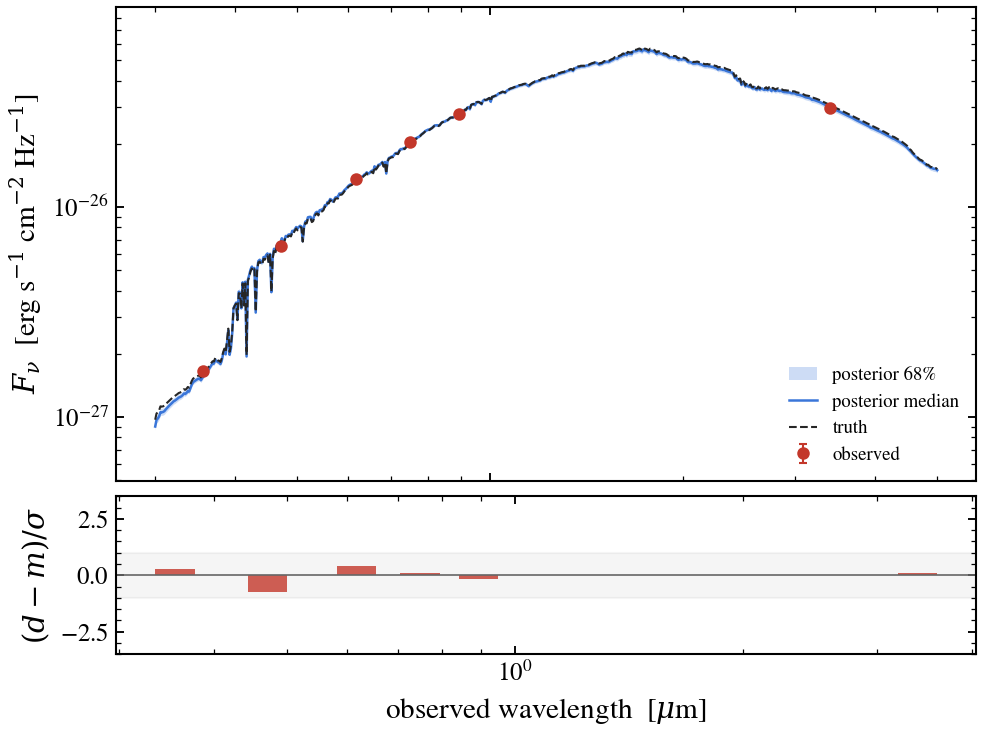

In [7]:
WAVE_OBS = np.geomspace(3000.0, 5e4, 600)
z_truth = float(truth_full["redshift"])
dl_cm = cosmology.luminosity_distance(z_truth)


def obs_fnu(params):
    rest = sed_model.predict_rest_sed(params, wave=WAVE_OBS / (1.0 + z_truth))
    return np.asarray(lnu_to_fnu(jnp.asarray(rest.sed), dl_cm, z_truth))


spec_draws = np.stack([obs_fnu(p) for p in draw_dicts(60)])
spec_lo, spec_med, spec_hi = np.percentile(spec_draws, [16, 50, 84], axis=0)
spec_truth = obs_fnu(truth_full)

phot_draws = np.asarray(jax.vmap(lambda p: forward.predict(p)["phot_fnu"])(draws))
phot_med = np.median(phot_draws, axis=0)

fig = plt.figure(figsize=(7.4, 5.6))
gs = fig.add_gridspec(2, 1, height_ratios=[3, 1], hspace=0.05)
ax, ax_res = fig.add_subplot(gs[0]), fig.add_subplot(gs[1])

wave_um = WAVE_OBS / 1e4
ax.fill_between(wave_um, spec_lo, spec_hi, color=C_POST, alpha=0.25, lw=0, label="posterior 68%")
ax.plot(wave_um, spec_med, color=C_POST, lw=1.2, label="posterior median")
ax.plot(wave_um, spec_truth, color=C_TRUTH, lw=1.0, ls="--", label="truth")
ax.errorbar(
    wave_eff_um,
    flux_obs,
    yerr=noise,
    fmt="o",
    color=C_DATA,
    ms=5,
    capsize=2,
    elinewidth=1.0,
    label="observed",
    zorder=5,
)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylabel(r"$F_\nu$  [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]")
ax.set_ylim(0.3 * flux_obs.min(), 3 * flux_obs.max())
ax.legend(frameon=False, fontsize=9, loc="lower right")
plt.setp(ax.get_xticklabels(), visible=False)

resid = (flux_obs - phot_med) / noise
ax_res.axhspan(-1, 1, alpha=0.08, color="0.5")
ax_res.axhline(0, color="0.4", lw=0.8)
ax_res.bar(wave_eff_um, resid, width=wave_eff_um * 0.12, color=C_DATA, alpha=0.8)
ax_res.set_xscale("log")
ax_res.set_ylim(-3.5, 3.5)
ax_res.set_xlabel(r"observed wavelength  [$\mu$m]")
ax_res.set_ylabel(r"$(d-m)/\sigma$")
fig.savefig(FIG_DIR / "00_posterior_sed.png", dpi=300, bbox_inches="tight")

## Star-formation history

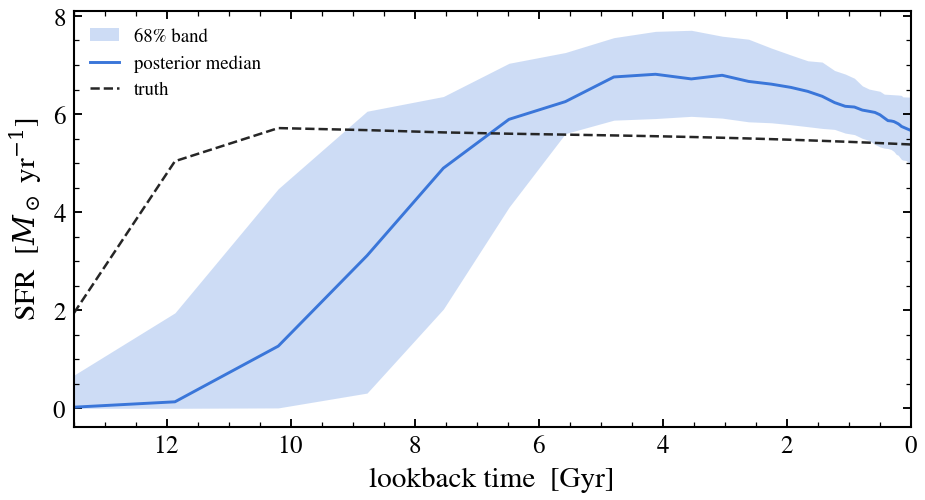

In [8]:
def sfh(p):
    s = sed_model.predict_state(p)
    return (
        np.asarray(s.derived["sfh_grid_lbt_yr"]) / 1e9,
        np.asarray(s.derived["sfr_history"]),
    )


sfr_draws, lbt = [], None
for p in draw_dicts(120):
    lbt_i, sfr_i = sfh(p)
    sfr_draws.append(sfr_i)
    if lbt is None:
        lbt = lbt_i
sfr_draws = np.stack(sfr_draws)
sfr_lo, sfr_med, sfr_hi = np.percentile(sfr_draws, [16, 50, 84], axis=0)
lbt_t, sfr_t = sfh(truth_full)

fig_sfh, ax_sfh = plt.subplots(figsize=(7.2, 3.6))
ax_sfh.fill_between(lbt, sfr_lo, sfr_hi, color=C_POST, alpha=0.25, lw=0, label="68% band")
ax_sfh.plot(lbt, sfr_med, color=C_POST, lw=1.4, label="posterior median")
ax_sfh.plot(lbt_t, sfr_t, color=C_TRUTH, ls="--", lw=1.2, label="truth")
ax_sfh.invert_xaxis()
ax_sfh.set_xlim(13.5, 0)
ax_sfh.set_xlabel("lookback time  [Gyr]")
ax_sfh.set_ylabel(r"SFR  [$M_\odot$ yr$^{-1}$]")
ax_sfh.legend(frameon=False, fontsize=9)
fig_sfh.savefig(FIG_DIR / "00_sfh.png", dpi=300, bbox_inches="tight")

## Corner

Free parameters plus derived quantities (`stellar_mass`, `sfr_100myr`,
`sfr_10myr`, in log₁₀), truth dashed.

W0523 18:02:15.154103 2398409 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0523 18:02:15.504978 2398409 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


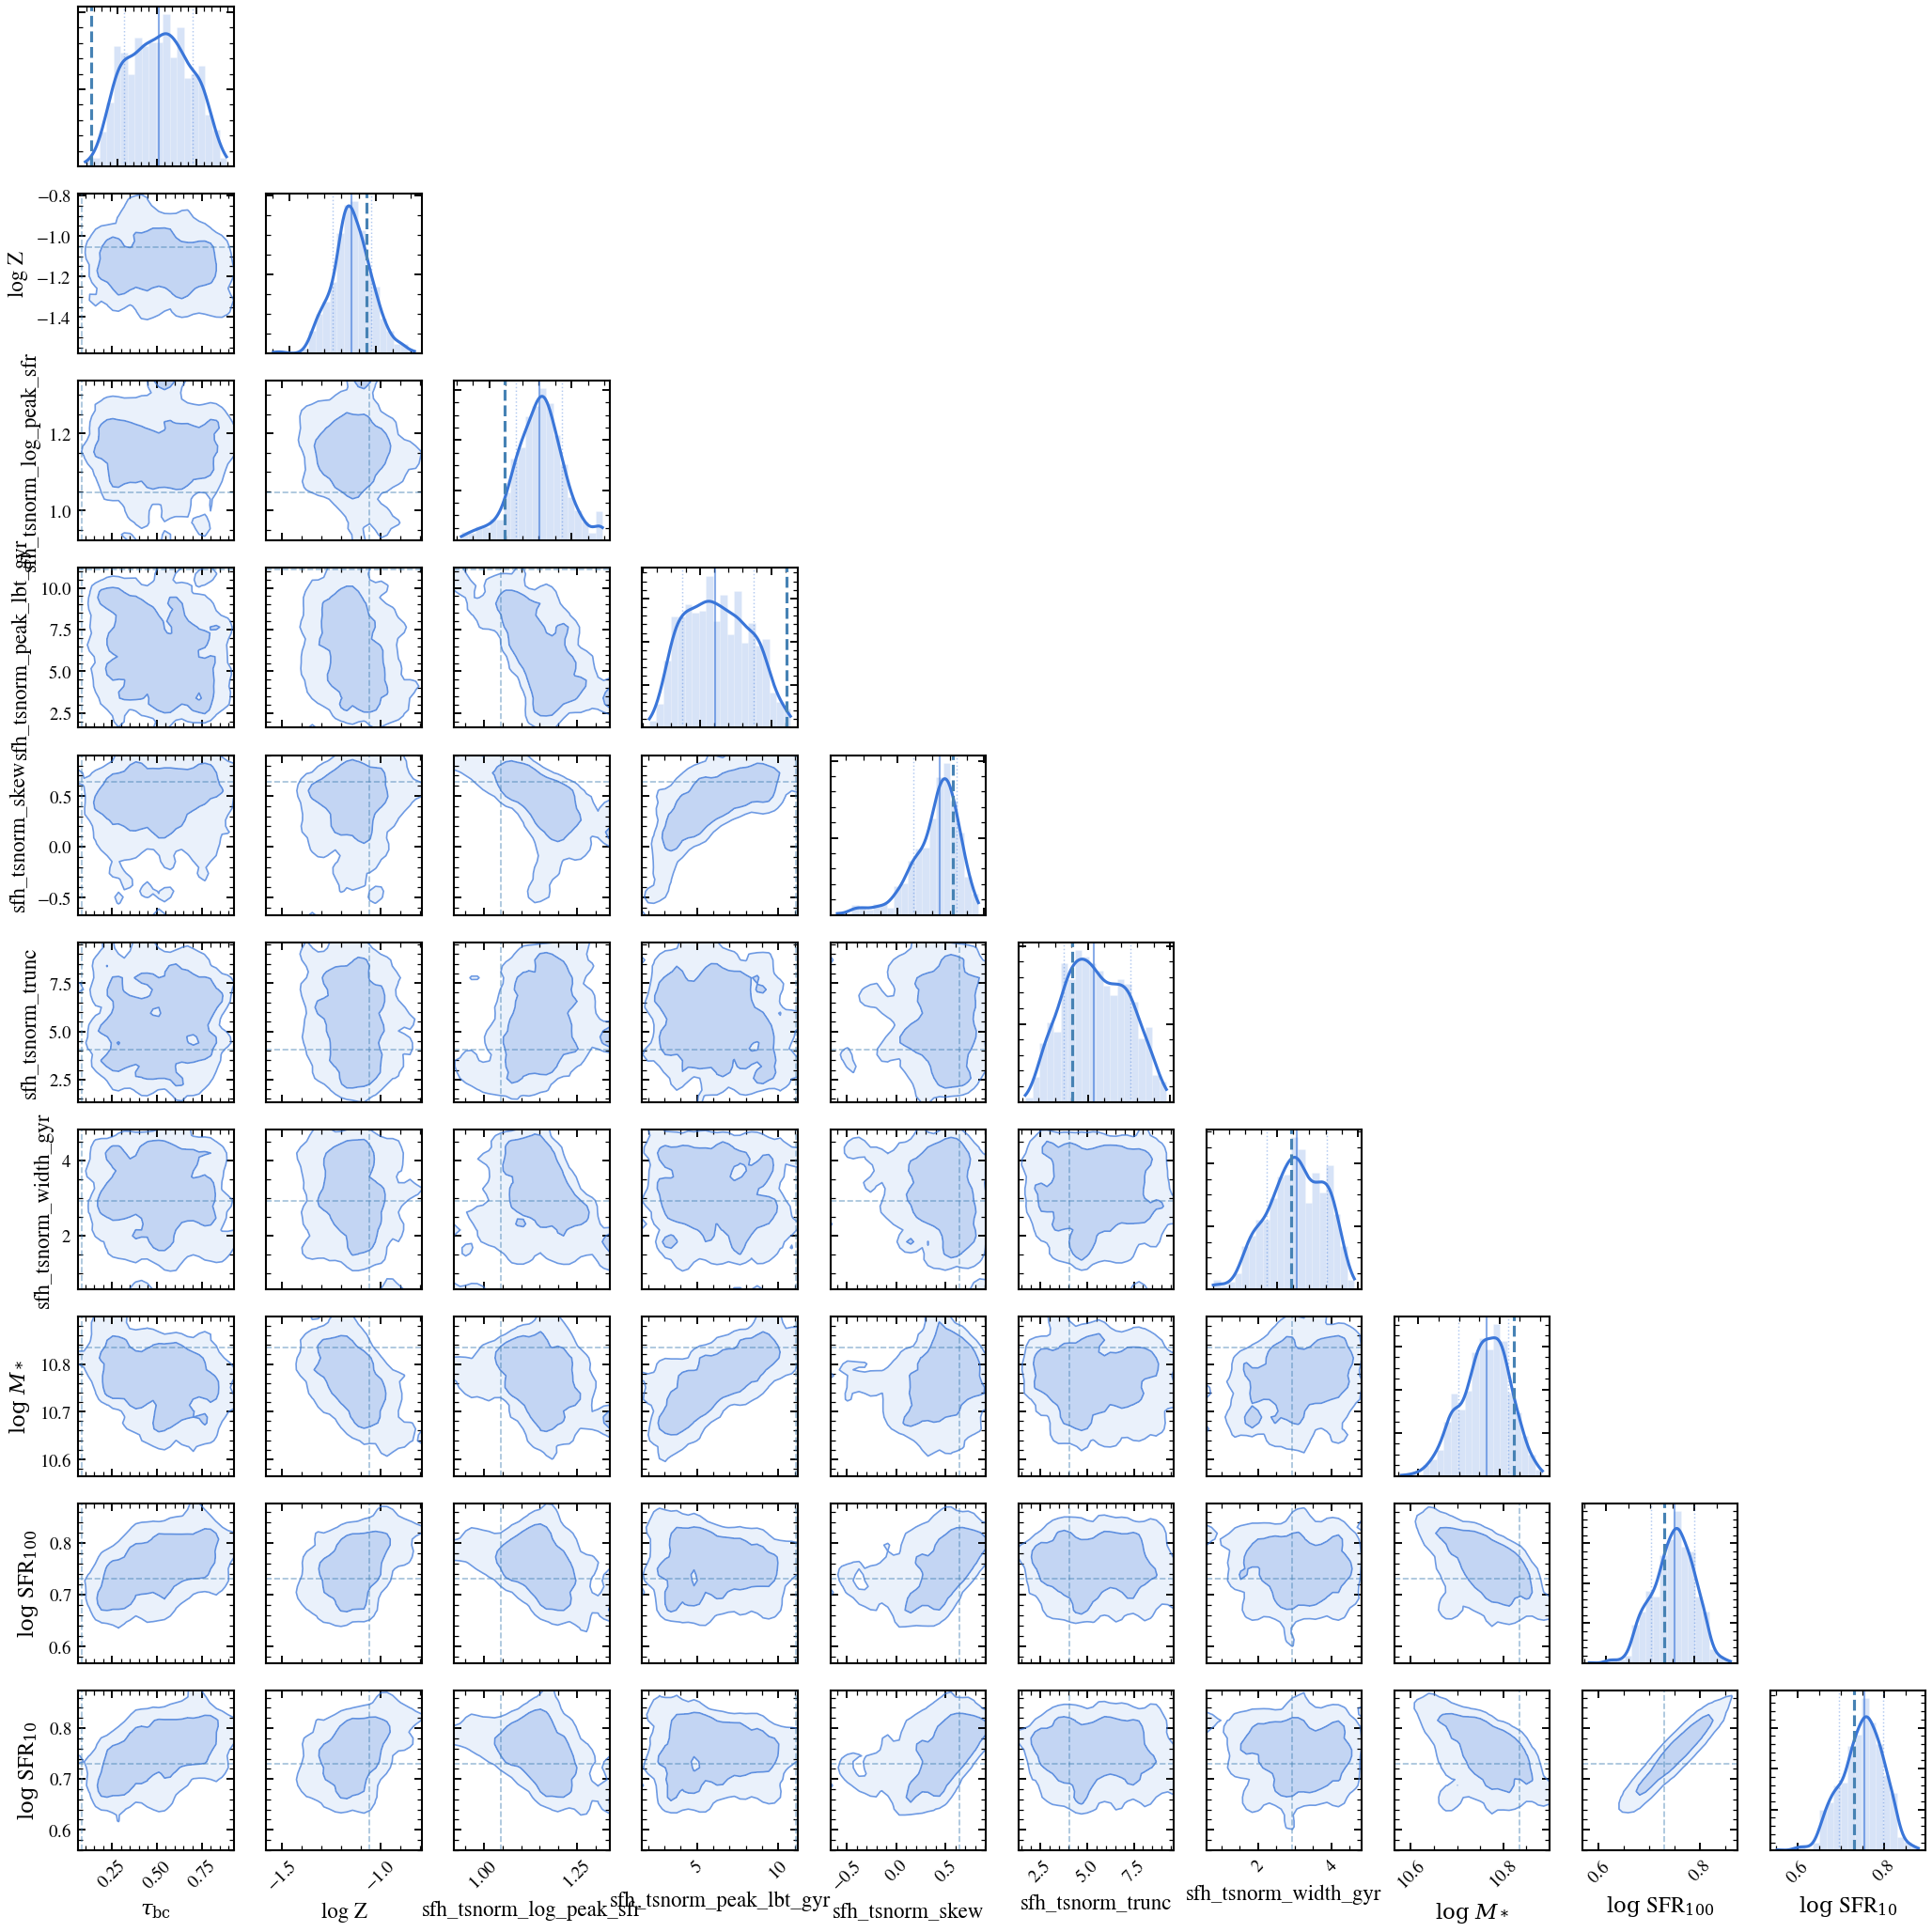

In [9]:
fig_corner = posterior.plot_corner(truths=truth_full, color=C_POST)
fig_corner.savefig(FIG_DIR / "00_corner.png", dpi=300, bbox_inches="tight")